# Deutsch and Bernstein-Vazirani Algorithms

This notebook is designed to help you understand and implement two foundational quantum algorithms using Qiskit: **Deutsch's algorithm** and the **Bernstein-Vazirani algorithm**.

We will guide you through step-by-step exercises, with some parts for you to complete.

## Exercise 1: Deutsch's Algorithm

The goal of Deutsch's algorithm is to determine whether a binary function $ f: \{0,1\} \rightarrow \{0,1\} $ is **constant** (always returns 0 or 1) or **balanced** (returns 0 for one input and 1 for the other).

We will implement and test all possible functions.

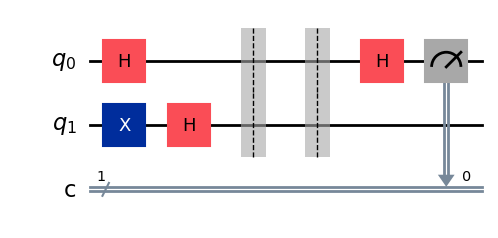

In [1]:
from qiskit import QuantumCircuit
import qiskit_aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Deutsch Oracle: constant function f(x) = 0
def deutsch_oracle_constant0(circuit):
    pass

# Deutsch algorithm template
def deutsch_algorithm(oracle_func):
    qc = QuantumCircuit(2, 1)
    qc.x(1)
    qc.h([0, 1])
    
    qc.barrier()
    oracle_func(qc)
    qc.barrier()
    
    qc.h(0)
    qc.measure(0, 0)
    return qc

# Run circuit and show results
def run_circuit(qc):
    backend = qiskit_aer.QasmSimulator()
    result = backend.run(qc, shots=1024).result()
    counts = result.get_counts(qc)
    return counts

# Example: run with one oracle
qc_example = deutsch_algorithm(deutsch_oracle_constant0)
qc_example.draw('mpl')

Now let's visualize the outcome:

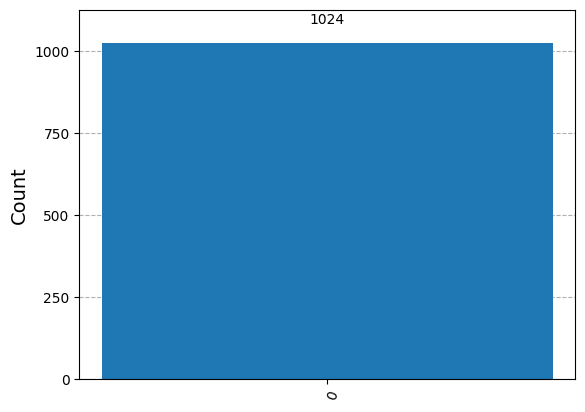

In [2]:
counts = run_circuit(qc_example)
plot_histogram(counts)

As expected, we measure 0 since the function is constant.
Now implement all the other oracles, draw the circuits and plot the histograms of the outcomes.

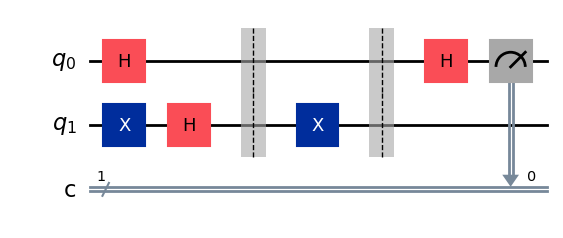

In [3]:
# Deutsch Oracle: constant function f(x) = 1
def deutsch_oracle_constant1(circuit):
    circuit.x(1)
    pass # TODO

# Example: run with one oracle
qc_constant1 = deutsch_algorithm(deutsch_oracle_constant1)
qc_constant1.draw('mpl')

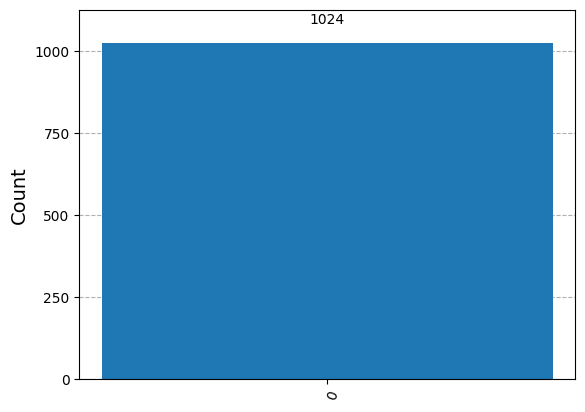

In [4]:
counts_constant1 = run_circuit(qc_constant1)
plot_histogram(counts_constant1)

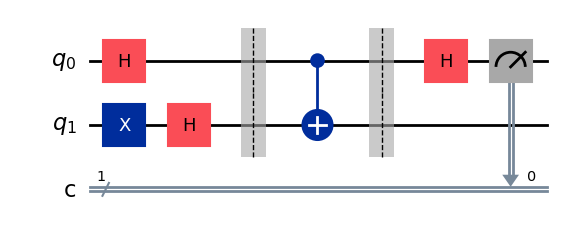

In [5]:
# Deutsch Oracle: balanced function f(x) = x
def deutsch_oracle_balanced_identity(circuit):
    circuit.cx(0,1)
    pass # TODO

# Example: run with one oracle
qc_balanced_identity = deutsch_algorithm(deutsch_oracle_balanced_identity)
qc_balanced_identity.draw('mpl')

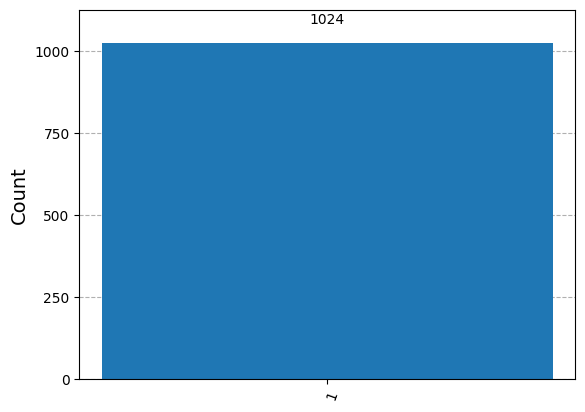

In [6]:
counts_balanced_identity = run_circuit(qc_balanced_identity)
plot_histogram(counts_balanced_identity)

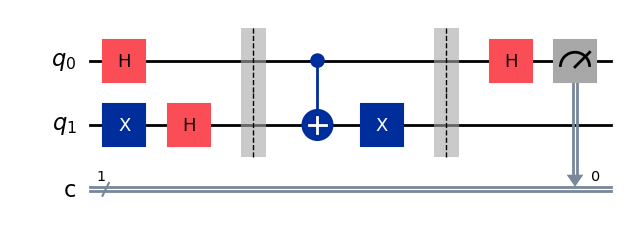

In [7]:
# Deutsch Oracle: balanced function f(x) = not(x)
def deutsch_oracle_balanced_not(circuit):
    circuit.cx(0,1)
    circuit.x(1)
    pass # TODO

# Example: run with one oracle
qc_balanced_not = deutsch_algorithm(deutsch_oracle_balanced_not)
qc_balanced_not.draw('mpl')

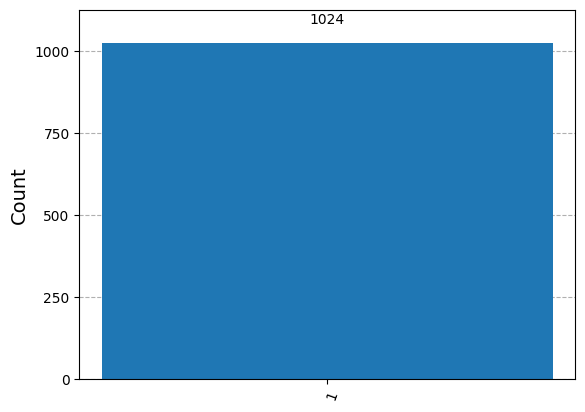

In [8]:
counts_balanced_not = run_circuit(qc_balanced_not)
plot_histogram(counts_balanced_not)

## Exercise 2: Bernstein-Vazirani Algorithm

The Bernstein-Vazirani algorithm solves the problem of determining a secret string $ s \in \{0,1\}^n $, given a function $ f(x) = s \cdot x \mod 2 $.

The function is implemented as an oracle. The algorithm determines $ s $ with a single evaluation.

Implement the oracle of the Bernstein-Vazirani algorithm, given a generic bitstring $s$. Remember that, in qiskit, the least significant qubit is the **upmost qubit** in the quantum circuit.

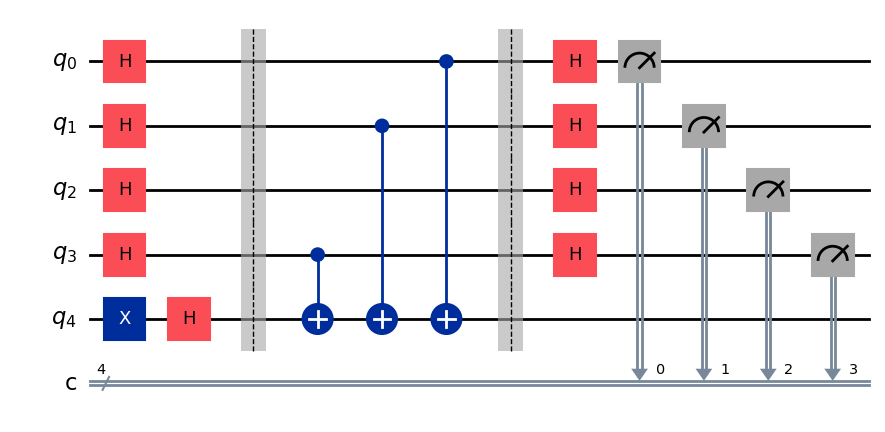

In [9]:
def bv_oracle(secret_string):
    n = len(secret_string)
    qc = QuantumCircuit(n+1)
    qc.barrier()
    for i, bit in enumerate(secret_string):
        if bit == '1':
            qc.cx(n-1-i, n)
    qc.barrier()
    return qc

def bernstein_vazirani(secret_string):
    n = len(secret_string)
    qc = QuantumCircuit(n+1, n)

    qc.x(n)
    qc.h(range(n+1))

    oracle = bv_oracle(secret_string)
    qc.compose(oracle, inplace=True)

    qc.h(range(n))
    qc.measure(range(n), range(n))

    return qc

# Run an example
secret = '1011'
bv_circuit = bernstein_vazirani(secret)
bv_circuit.draw('mpl')

In [10]:
counts = run_circuit(bv_circuit)
print("Measured:", list(counts.keys())[0])

Measured: 1011


**Change the `secret` string, change also the number of qubits if you want and see if the measurement matches the expected result!**
For example, try:
`10101010`
`1100110011`
`100010101110`